# Install dependency

In [17]:
!pip -q install ucimlrepo

# Import libraries

In [18]:
import os
import json
import shutil
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:.4f}")

# Download the dataset

In [19]:
# UCI Dataset ID 602: Dry Bean Dataset
dry_bean = fetch_ucirepo(id=602)

X = dry_bean.data.features.copy()
y = dry_bean.data.targets.copy()

if isinstance(y, pd.DataFrame):
    y = y.iloc[:, 0]

y = y.astype(str).str.strip()
y.name = "Class"

print("Dataset shape:", X.shape)
print("Number of features:", X.shape[1])
print("Number of instances:", X.shape[0])
print("Target column:", y.name)
print("\nClass distribution:")
print(y.value_counts())

Dataset shape: (13611, 16)
Number of features: 16
Number of instances: 13611
Target column: Class

Class distribution:
Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64


# Inspect and clean the data

In [20]:
print("First five rows:")
display(X.head())

First five rows:


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRatio,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,Roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
0,28395,610.2910,208.1781,173.8887,1.1972,0.5498,28715,190.1411,0.7639,0.9889,0.9580,0.9134,0.0073,0.0031,0.8342,0.9987
1,28734,638.0180,200.5248,182.7344,1.0974,0.4118,29172,191.2728,0.7840,0.9850,0.8870,0.9539,0.0070,0.0036,0.9099,0.9984
2,29380,624.1100,212.8261,175.9311,1.2097,0.5627,29690,193.4109,0.7781,0.9896,0.9478,0.9088,0.0072,0.0030,0.8259,0.9991
3,30008,645.8840,210.5580,182.5165,1.1536,0.4986,30724,195.4671,0.7827,0.9767,0.9039,0.9283,0.0070,0.0032,0.8618,0.9942
4,30140,620.1340,201.8479,190.2793,1.0608,0.3337,30417,195.8965,0.7731,0.9909,0.9849,0.9705,0.0067,0.0037,0.9419,0.9992


In [21]:
print("\nFeature data types:")
display(X.dtypes)


Feature data types:


,0
Area,int64
Perimeter,float64
MajorAxisLength,float64
MinorAxisLength,float64
AspectRatio,float64
Eccentricity,float64
ConvexArea,int64
EquivDiameter,float64
Extent,float64
Solidity,float64


In [22]:
print("\nMissing values:")
display(X.isnull().sum().to_frame("Missing Values"))



Missing values:


,Missing Values
Area,0
Perimeter,0
MajorAxisLength,0
MinorAxisLength,0
AspectRatio,0
Eccentricity,0
ConvexArea,0
EquivDiameter,0
Extent,0
Solidity,0


In [23]:
print("\nDuplicate feature rows:", X.duplicated().sum())

print("\nDescriptive statistics:")
display(X.describe().T)


Duplicate feature rows: 68

Descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
Area,13611.0000,53048.2845,29324.0957,20420.0000,36328.0000,44652.0000,61332.0000,254616.0000
Perimeter,13611.0000,855.2835,214.2897,524.7360,703.5235,794.9410,977.2130,1985.3700
MajorAxisLength,13611.0000,320.1419,85.6942,183.6012,253.3036,296.8834,376.4950,738.8602
MinorAxisLength,13611.0000,202.2707,44.9701,122.5127,175.8482,192.4317,217.0317,460.1985
AspectRatio,13611.0000,1.5832,0.2467,1.0249,1.4323,1.5511,1.7071,2.4303
Eccentricity,13611.0000,0.7509,0.0920,0.2190,0.7159,0.7644,0.8105,0.9114
ConvexArea,13611.0000,53768.2002,29774.9158,20684.0000,36714.5000,45178.0000,62294.0000,263261.0000
EquivDiameter,13611.0000,253.0642,59.1771,161.2438,215.0680,238.4380,279.4465,569.3744
Extent,13611.0000,0.7497,0.0491,0.5553,0.7186,0.7599,0.7869,0.8662
Solidity,13611.0000,0.9871,0.0047,0.9192,0.9857,0.9883,0.9900,0.9947


# Visualize class distribution

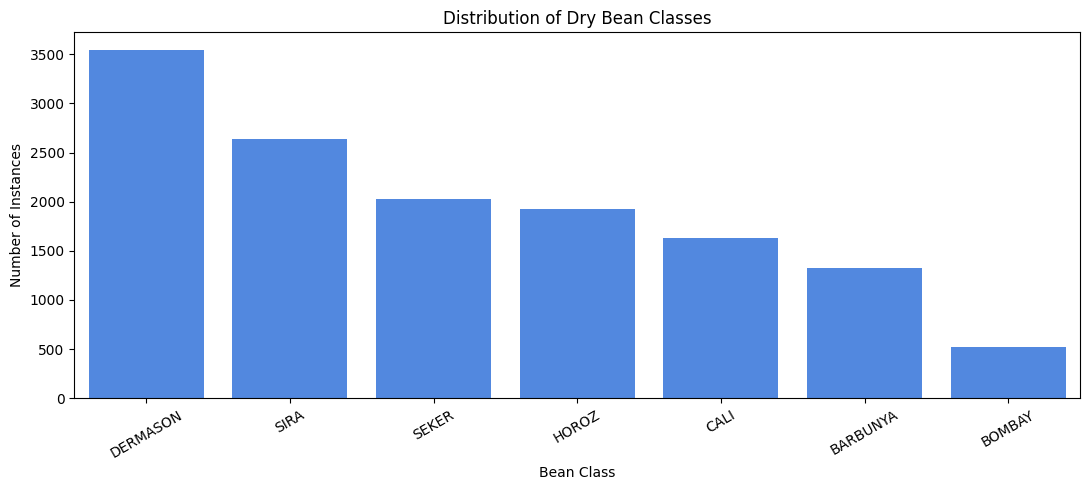

In [24]:
plt.figure(figsize=(11, 5))

class_order = y.value_counts().index
sns.countplot(x=y, order=class_order, color="#3B82F6")

plt.title("Distribution of Dry Bean Classes")
plt.xlabel("Bean Class")
plt.ylabel("Number of Instances")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Create training and test sets

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (10888, 16)
Test set: (2723, 16)


In [27]:
print("\nTraining class distribution:")
display(y_train.value_counts().sort_index())


Training class distribution:


,count
Class,
BARBUNYA,1057
BOMBAY,418
CALI,1304
DERMASON,2837
HOROZ,1542
SEKER,1621
SIRA,2109


In [29]:
print("\nTest class distribution:")
display(y_test.value_counts().sort_index())


Test class distribution:


,count
Class,
BARBUNYA,265
BOMBAY,104
CALI,326
DERMASON,709
HOROZ,386
SEKER,406
SIRA,527


# Define the five models

In [37]:
scaled_preprocessing = [
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
]

unscaled_preprocessing = [
    ("imputer", SimpleImputer(strategy="median"))
]

In [38]:
models = {
    "Logistic Regression": Pipeline([
        *scaled_preprocessing,
        ("classifier", LogisticRegression(
            max_iter=3000,
            random_state=RANDOM_STATE
        ))
    ]),

    "Decision Tree": Pipeline([
        *unscaled_preprocessing,
        ("classifier", DecisionTreeClassifier(
            random_state=RANDOM_STATE
        ))
    ]),

    "K-Nearest Neighbors": Pipeline([
        *scaled_preprocessing,
        ("classifier", KNeighborsClassifier(
            n_neighbors=5
        ))
    ]),

    "Gaussian Naive Bayes": Pipeline([
        *scaled_preprocessing,
        ("classifier", GaussianNB())
    ]),

    "Random Forest": Pipeline([
        *unscaled_preprocessing,
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ])
}

print("Models selected:")
for model_name in models:
    print("-", model_name)

Models selected:
- Logistic Regression
- Decision Tree
- K-Nearest Neighbors
- Gaussian Naive Bayes
- Random Forest


# Train and evaluate every model

In [39]:
results = []
predictions = {}
probabilities = {}
reports = {}
trained_models = {}

for model_name, model in models.items():
    print(f"Training {model_name}...")

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_probability = model.predict_proba(X_test)

    model_classes = model.named_steps["classifier"].classes_

    accuracy = accuracy_score(y_test, y_pred)

    auc = roc_auc_score(
        y_test,
        y_probability,
        labels=model_classes,
        multi_class="ovr",
        average="macro"
    )

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    mcc = matthews_corrcoef(y_test, y_pred)

    results.append({
        "ML Model Name": model_name,
        "Accuracy": accuracy,
        "AUC": auc,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "MCC": mcc
    })

    predictions[model_name] = y_pred
    probabilities[model_name] = y_probability
    trained_models[model_name] = model

    reports[model_name] = classification_report(
        y_test,
        y_pred,
        output_dict=True,
        zero_division=0
    )

print("\nAll models trained successfully.")

Training Logistic Regression...
Training Decision Tree...
Training K-Nearest Neighbors...
Training Gaussian Naive Bayes...
Training Random Forest...

All models trained successfully.


# Display the comparison table

In [40]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1",
    ascending=False
).reset_index(drop=True)

metric_columns = [
    "Accuracy",
    "AUC",
    "Precision",
    "Recall",
    "F1",
    "MCC"
]

display(
    results_df.style
    .format({column: "{:.4f}" for column in metric_columns})
    .background_gradient(subset=metric_columns, cmap="Blues")
)

winner = results_df.iloc[0]["ML Model Name"]

print(f"Overall winner based on weighted F1 score: {winner}")

,ML Model Name,Accuracy,AUC,Precision,Recall,F1,MCC
0,Random Forest,0.9210,0.9934,0.9211,0.9210,0.9210,0.9045
1,Logistic Regression,0.9207,0.9948,0.9215,0.9207,0.9209,0.9042
2,K-Nearest Neighbors,0.9166,0.9833,0.9174,0.9166,0.9168,0.8992
3,Gaussian Naive Bayes,0.8979,0.9916,0.9007,0.8979,0.8981,0.8773
4,Decision Tree,0.8920,0.9450,0.8917,0.8920,0.8916,0.8696


Overall winner based on weighted F1 score: Random Forest


# Plot the model comparison

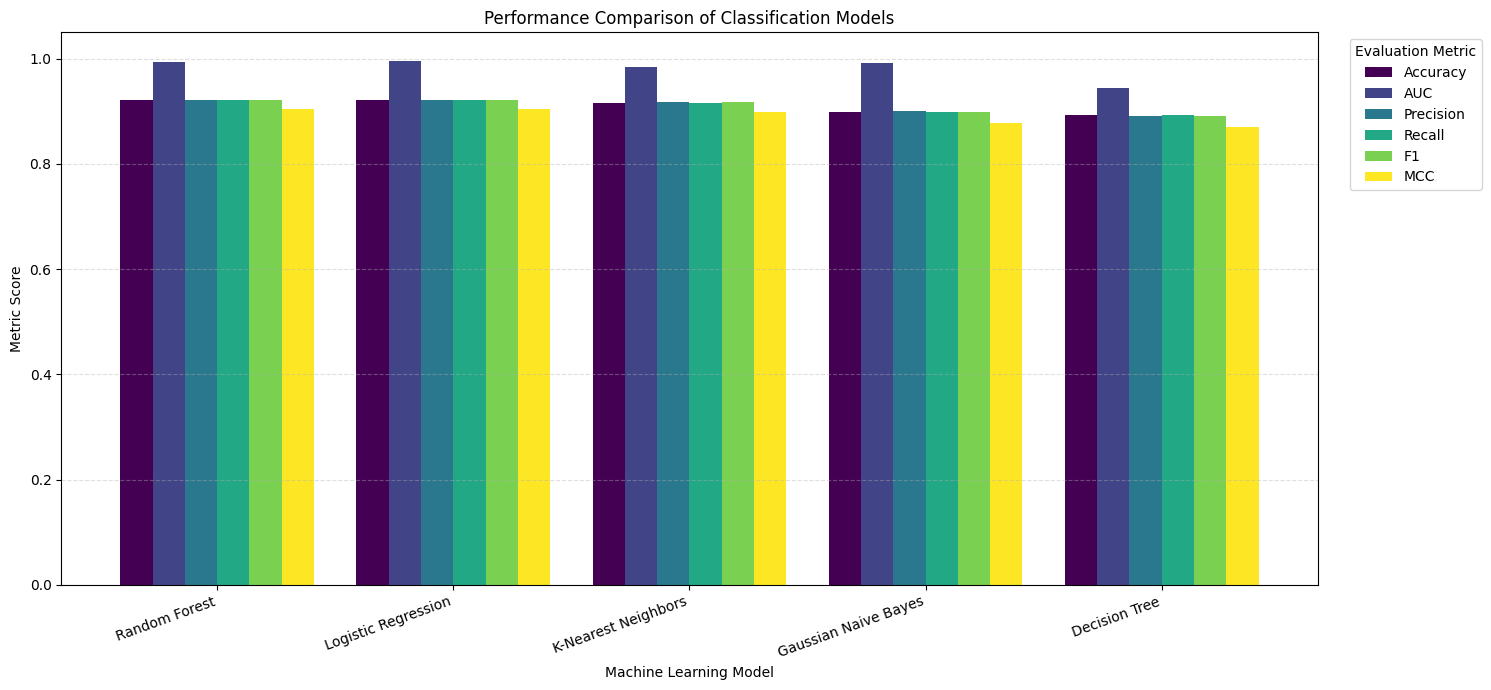

In [41]:
plot_df = results_df.set_index("ML Model Name")[metric_columns]

ax = plot_df.plot(
    kind="bar",
    figsize=(15, 7),
    colormap="viridis",
    width=0.82
)

plt.title("Performance Comparison of Classification Models")
plt.xlabel("Machine Learning Model")
plt.ylabel("Metric Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=20, ha="right")
plt.legend(
    title="Evaluation Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# Confusion matrices

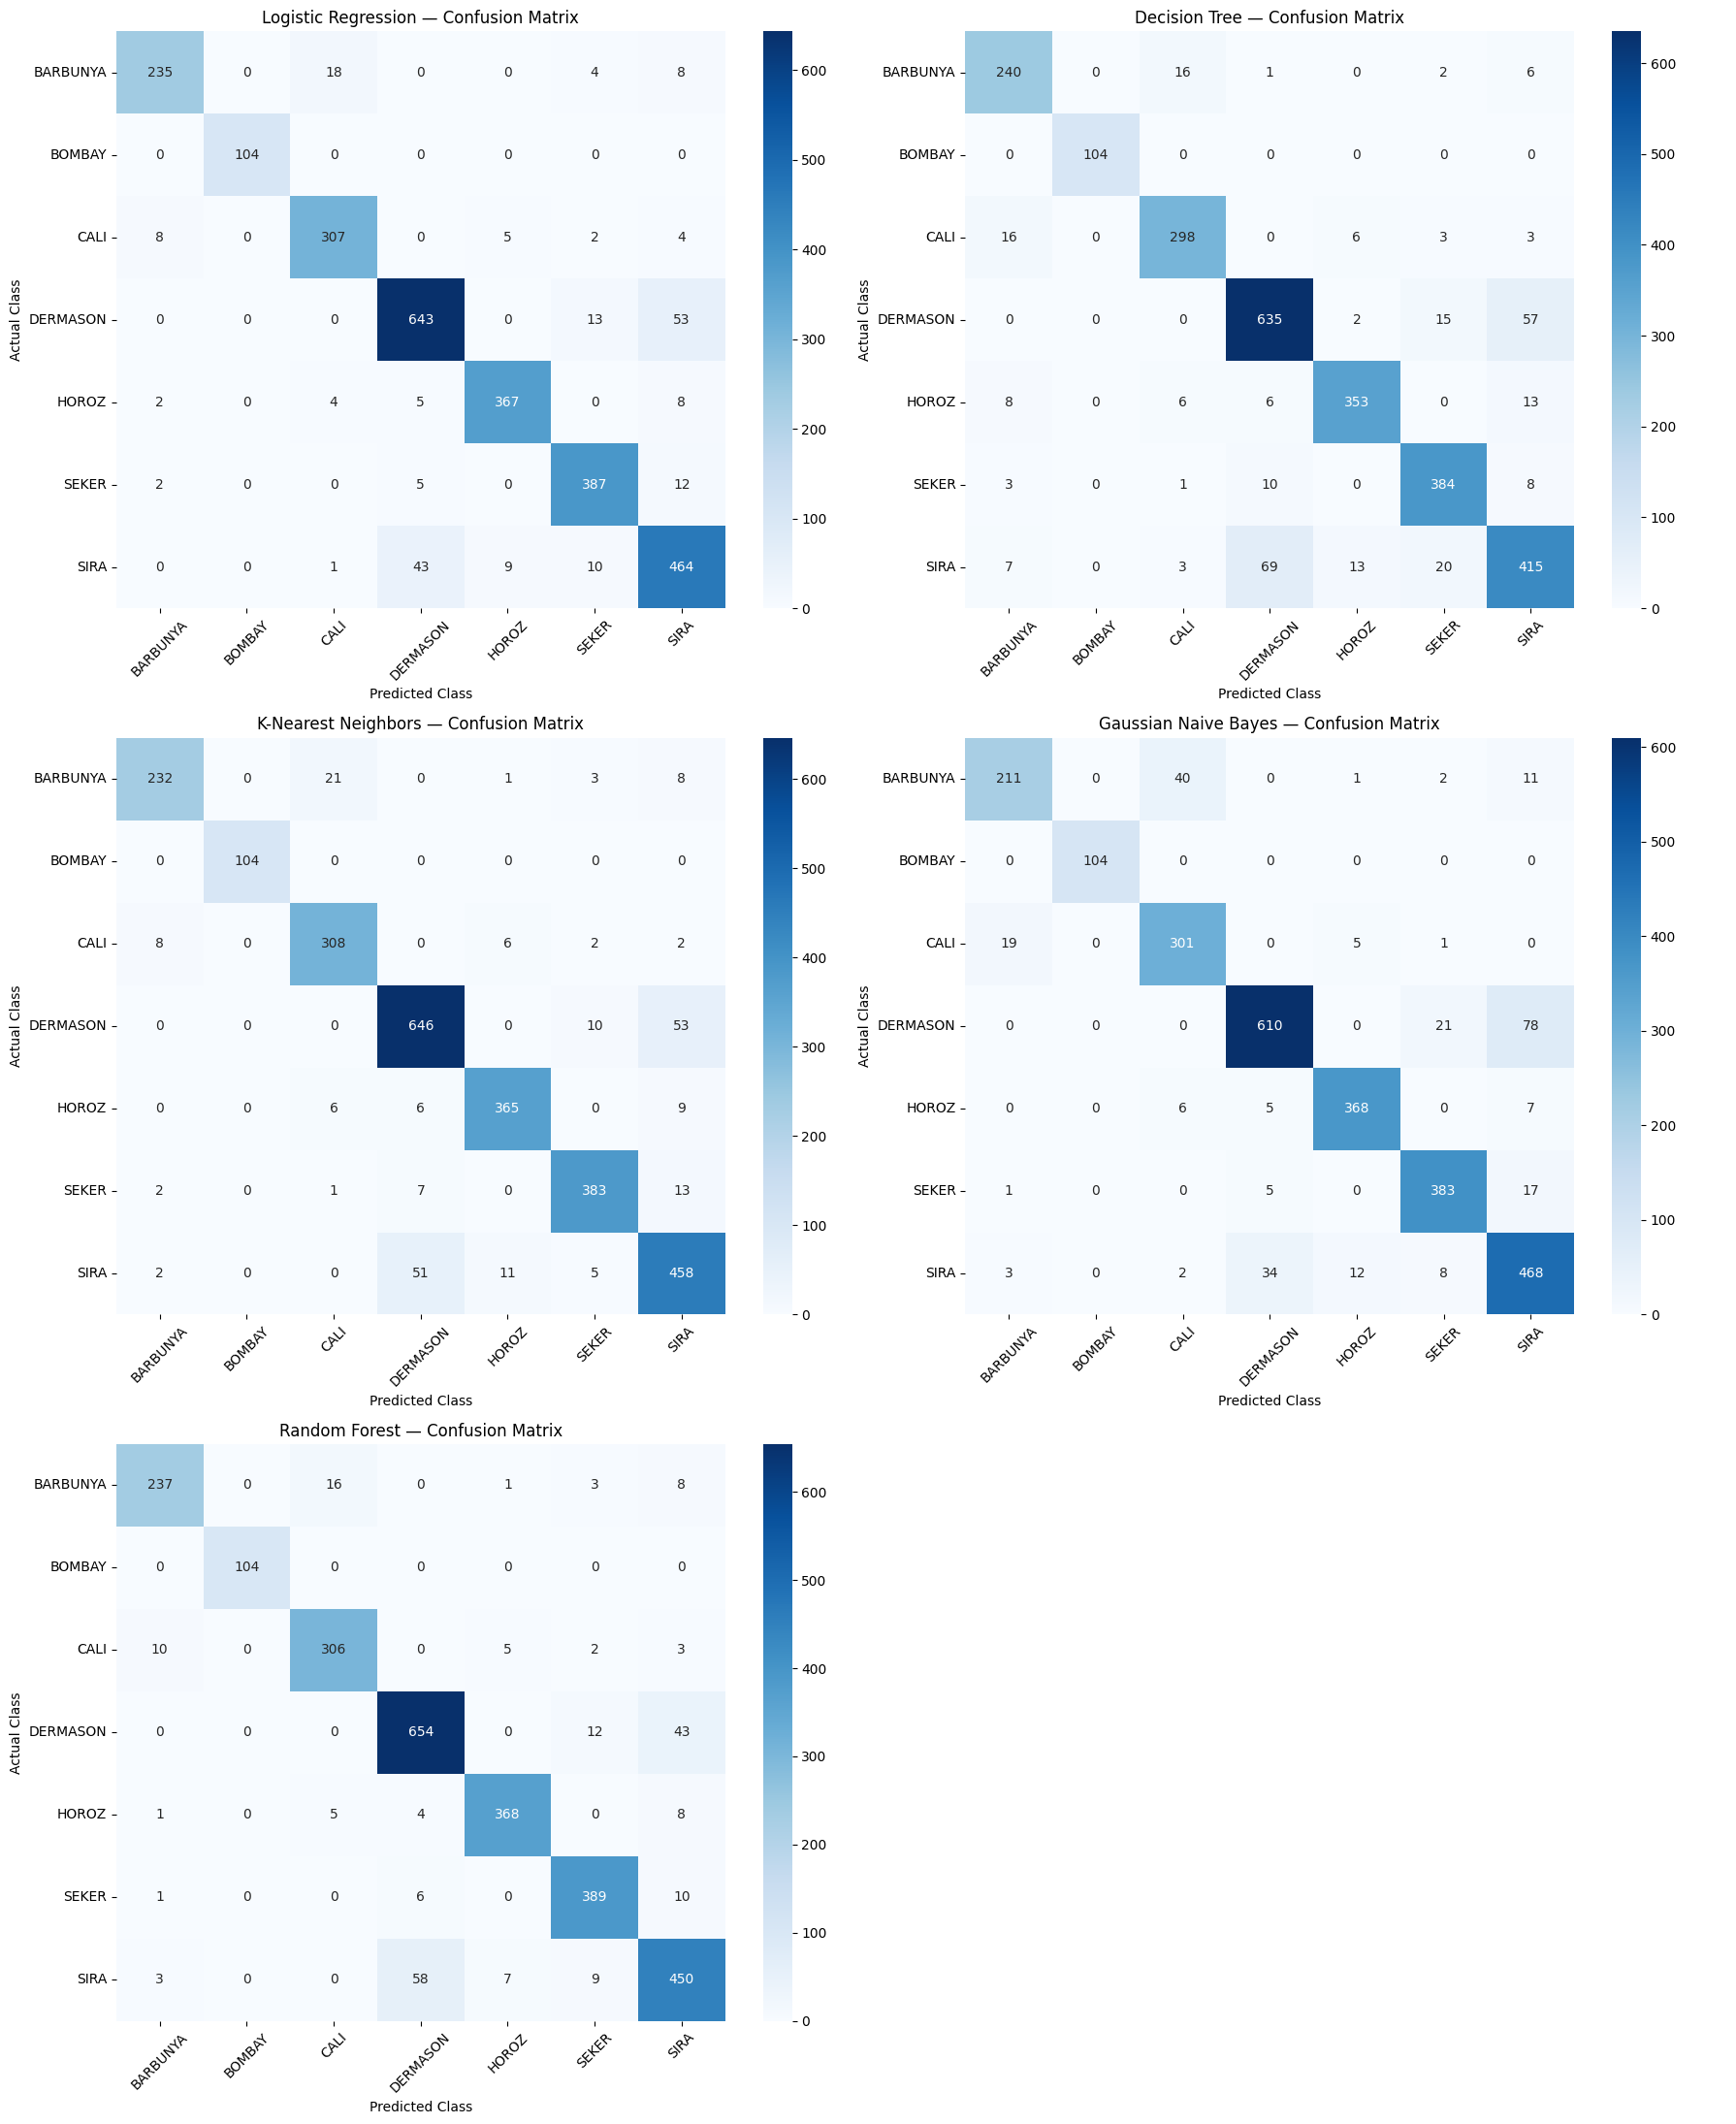

In [42]:
class_names = sorted(y.unique())

fig, axes = plt.subplots(3, 2, figsize=(18, 22))
axes = axes.flatten()

for index, model_name in enumerate(models.keys()):
    matrix = confusion_matrix(
        y_test,
        predictions[model_name],
        labels=class_names
    )

    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        ax=axes[index]
    )

    axes[index].set_title(f"{model_name} — Confusion Matrix")
    axes[index].set_xlabel("Predicted Class")
    axes[index].set_ylabel("Actual Class")
    axes[index].tick_params(axis="x", rotation=45)
    axes[index].tick_params(axis="y", rotation=0)

axes[-1].axis("off")

plt.tight_layout()
plt.show()

# Classification reports

In [43]:
for model_name in models:
    print("=" * 90)
    print(model_name)
    print("=" * 90)

    print(
        classification_report(
            y_test,
            predictions[model_name],
            zero_division=0
        )
    )

Logistic Regression
              precision    recall  f1-score   support

    BARBUNYA       0.95      0.89      0.92       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.93      0.94      0.94       326
    DERMASON       0.92      0.91      0.92       709
       HOROZ       0.96      0.95      0.96       386
       SEKER       0.93      0.95      0.94       406
        SIRA       0.85      0.88      0.86       527

    accuracy                           0.92      2723
   macro avg       0.93      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723

Decision Tree
              precision    recall  f1-score   support

    BARBUNYA       0.88      0.91      0.89       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.92      0.91      0.92       326
    DERMASON       0.88      0.90      0.89       709
       HOROZ       0.94      0.91      0.93       386
       SEKER       0.91      0.95      0.93 

# Observations table

In [44]:
def create_observation(row, winner_name):
    model_name = row["ML Model Name"]

    if model_name == winner_name:
        return (
            f"This model achieved the highest weighted F1 score "
            f"({row['F1']:.4f}) and was selected as the overall winner."
        )

    return (
        f"This model achieved accuracy of {row['Accuracy']:.4f}, "
        f"macro AUC of {row['AUC']:.4f}, weighted F1 of "
        f"{row['F1']:.4f}, and MCC of {row['MCC']:.4f}."
    )

observations_df = results_df[
    ["ML Model Name", "Accuracy", "AUC", "F1", "MCC"]
].copy()

observations_df["Observation about model performance"] = (
    observations_df.apply(
        lambda row: create_observation(row, winner),
        axis=1
    )
)

observations_df = observations_df[
    ["ML Model Name", "Observation about model performance"]
]

overall_row = pd.DataFrame([{
    "ML Model Name": "Overall Winner",
    "Observation about model performance": (
        f"{winner} produced the highest weighted F1 score on the "
        "stratified test set."
    )
}])

observations_df = pd.concat(
    [observations_df, overall_row],
    ignore_index=True
)

display(observations_df)

,ML Model Name,Observation about model performance
0,Random Forest,This model achieved the highest weighted F1 sc...
1,Logistic Regression,"This model achieved accuracy of 0.9207, macro ..."
2,K-Nearest Neighbors,"This model achieved accuracy of 0.9166, macro ..."
3,Gaussian Naive Bayes,"This model achieved accuracy of 0.8979, macro ..."
4,Decision Tree,"This model achieved accuracy of 0.8920, macro ..."
5,Overall Winner,Random Forest produced the highest weighted F1...


# Save the models and outputs

In [45]:
os.makedirs("model", exist_ok=True)

safe_filenames = {
    "Logistic Regression": "logistic_regression.pkl",
    "Decision Tree": "decision_tree.pkl",
    "K-Nearest Neighbors": "knn.pkl",
    "Gaussian Naive Bayes": "gaussian_naive_bayes.pkl",
    "Random Forest": "random_forest.pkl"
}

for model_name, model in trained_models.items():
    output_path = os.path.join(
        "model",
        safe_filenames[model_name]
    )
    joblib.dump(model, output_path)

test_data = X_test.copy()
test_data["Class"] = y_test.values
test_data.to_csv("test_data.csv", index=False)

results_df.to_csv("model_comparison.csv", index=False)

observations_df.to_csv("model_observations.csv", index=False)

metadata = {
    "feature_names": X.columns.tolist(),
    "target_column": "Class",
    "class_names": sorted(y.unique().tolist()),
    "auc_method": "One-vs-rest macro average",
    "precision_recall_f1_method": "Weighted average",
    "random_state": RANDOM_STATE,
    "test_size": 0.20
}

with open("model/metadata.json", "w") as metadata_file:
    json.dump(metadata, metadata_file, indent=4)

print("Saved model files:")
for filename in os.listdir("model"):
    print("-", filename)

print("\nOther saved files:")
print("- test_data.csv")
print("- model_comparison.csv")
print("- model_observations.csv")

Saved model files:
- knn.pkl
- decision_tree.pkl
- random_forest.pkl
- gaussian_naive_bayes.pkl
- logistic_regression.pkl
- metadata.json

Other saved files:
- test_data.csv
- model_comparison.csv
- model_observations.csv
